In [1]:
import os
import glob

import numpy as np
import xarray as xr

import csv
import pop_tools
import gsw

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
import cartopy
import matplotlib.ticker as ticker
from matplotlib import animation, gridspec
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

import cmcrameri.cm as cmc 

ccrs = cartopy.crs
cfeature = cartopy.feature

nature_coast = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m',linewidth=0.5, edgecolor='black', facecolor='whitesmoke')

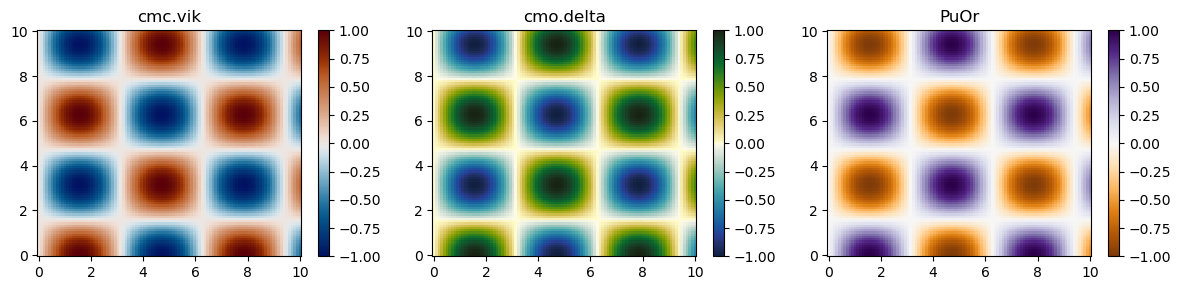

In [2]:
# Dummy data
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)
data = np.sin(X) * np.cos(Y)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
maps = [('cmc.vik', cmc.vik), ('cmo.delta', cmo.delta), ('PuOr', plt.cm.PuOr)]

for ax, (name, cmap) in zip(axes, maps):
    pc = ax.pcolormesh(X, Y, data, cmap=cmap, vmin=-1, vmax=1, shading='auto')
    ax.set_title(name)
    plt.colorbar(pc, ax=ax)
    
plt.tight_layout()
plt.savefig('Density_Cmap_Options.png', dpi=300)

In [3]:
# AMS widths in inches
one_col = 3.167  # 19 picas
two_col = 6.5    # 39 picas

# Set defaults
plt.rcParams.update({
    'figure.figsize': (two_col, two_col * 0.6),
    'font.size': 11,
    'axes.titlesize': 11,   # match global font size for titles
    'savefig.dpi': 300,
})

nature_coast = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m',linewidth=0.3, edgecolor='black', facecolor='whitesmoke')

In [4]:
grid_name = 'POP_gx1v7'
region_defs_lab = {'LabradorSea': [{'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [55.0, 65.0],'TLONG': [290., 335.]}}]} 
lab_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_lab, mask_name='lab')
lab_mask3d = lab_mask3d.sum('region') # apparently necessary even in this case

region_defs_irm = {'IrmingerSea': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [55., 65.],'TLONG': [300., 335.]}}]}
irm_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_irm, mask_name='irm')
irm_mask3d = irm_mask3d.sum('region')

region_defs_esp = {'ESP': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50., 65.],'TLONG': [335., 359.]}}],}
esp_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_esp, mask_name='esp')
esp_mask3d = esp_mask3d.sum('region')

region_defs_csp = {'NorthAtlantic': [{'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50., 55.],'TLONG': [300., 335.]}}],
                  'LabradorSea': [{'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [50., 55.]}}]}
csp_mask3d = pop_tools.region_mask_3d(grid_name, region_defs=region_defs_csp, mask_name='csp')
csp_mask3d = csp_mask3d.sum('region')

lab_mask3d = lab_mask3d.roll(nlon=-100)
irm_mask3d = irm_mask3d.roll(nlon=-100)
esp_mask3d = esp_mask3d.roll(nlon=-100)
csp_mask3d = csp_mask3d.roll(nlon=-100)

REGION_MAPS = [
    ('lab', 'Labrador Sea', lab_mask3d), 
    ('irm', 'Irminger Sea', irm_mask3d), 
    ('esp', 'Eastern SPNA', esp_mask3d), 
    ('csp', 'Central SPNA', csp_mask3d)
]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# for all

In [5]:
# --- File Paths ---
FILE_PATHS = {
    'increase': {
        'temp': '/Data/skd/scratch/innag3580/comp/composites/Above_combined_TEMP_3.0_40_20.nc',
        'salt': '/Data/skd/scratch/innag3580/comp/composites/Above_combined_SALT_3.0_40_20.nc'
    },
    'aa': { # <--- PLACEHOLDER: Please confirm these filenames
        'temp': '/Data/skd/scratch/innag3580/comp/composites/Below_combined_TEMP_2.0_40_20_aa_hist.nc', 
        'salt': '/Data/skd/scratch/innag3580/comp/composites/Below_combined_SALT_2.0_40_20_aa_hist.nc'
    },
    'ghg': { # <--- PLACEHOLDER: Please confirm these filenames
        'temp': '/Data/skd/scratch/innag3580/comp/composites/Below_combined_TEMP_3.0_40_20.nc',
        'salt': '/Data/skd/scratch/innag3580/comp/composites/Below_combined_SALT_3.0_40_20.nc'
    }
}

# --- Processing Function ---
def create_ds_dens(temp_file, salt_file):
    """Loads TEMP/SALT files, calculates sigma2 (DENS2), and returns a ds_dens dataset."""
    ds_temp = xr.open_dataset(temp_file)
    ds_salt = xr.open_dataset(salt_file)
    
    # 1. Calculate Conservative Temperature (CT)
    CT = gsw.conversions.CT_from_pt(ds_salt['SALT'], ds_temp['TEMP'])
    
    # 2. Calculate Potential Density (sigma2)
    sigma2 = gsw.density.sigma2(ds_salt['SALT'], CT)
    
    # 3. Convert to DataArray and integrate into a new ds_dens structure
    sigma2 = xr.DataArray(sigma2, name='DENS2', dims=ds_temp['TEMP'].dims, coords=ds_temp['TEMP'].coords)
    
    ds_dens_out = ds_temp.drop_vars('TEMP')
    ds_dens_out['DENS2'] = sigma2
    
    return ds_dens_out

In [6]:
ds_dens_increase = create_ds_dens(FILE_PATHS['increase']['temp'], FILE_PATHS['increase']['salt'])

In [7]:
ds_dens_aa = create_ds_dens(FILE_PATHS['aa']['temp'], FILE_PATHS['aa']['salt'])

In [8]:
ds_dens_ghg = create_ds_dens(FILE_PATHS['ghg']['temp'], FILE_PATHS['ghg']['salt'])

In [9]:
def calculate_weighted_anomaly(ds_dens_case, mask3d):
    """Calculates area-weighted regional mean and time anomaly."""
    
    # Mask density data for the region.
    dens_region = ds_dens_case.DENS2.where(mask3d == 1)
    
    # Define TAREA (area) as weights, masked by region.
    weights = ds_dens_case.TAREA.fillna(0)
    
    # Calculate Area-Weighted Mean (horizontal).
    region_mean_weighted = dens_region.weighted(weights).mean(dim=['nlat', 'nlon'])
    
    # Calculate Anomaly (subtract baseline mean of first 40 steps).
    anom_region = region_mean_weighted - region_mean_weighted.isel(time=slice(0,40)).mean('time')
    
    return anom_region

In [10]:
iteration_list = [
    ('increase', ds_dens_increase),
    ('aa', ds_dens_aa),
    ('ghg', ds_dens_ghg)
]

all_anomalies = {
    'increase': {},
    'aa': {},
    'ghg': {}
}

# Calculate Area-Weighted Anomaly
for file_key, ds_dens_case in iteration_list:
    for region_key, region_title, mask3d in REGION_MAPS:
        anom_region = calculate_weighted_anomaly(ds_dens_case, mask3d)
        all_anomalies[file_key][region_key] = (anom_region, region_title)

/tmp/ipykernel_1893249/2869746210.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.03, 1, 0.98], w_pad=0.7, h_pad=0.1)


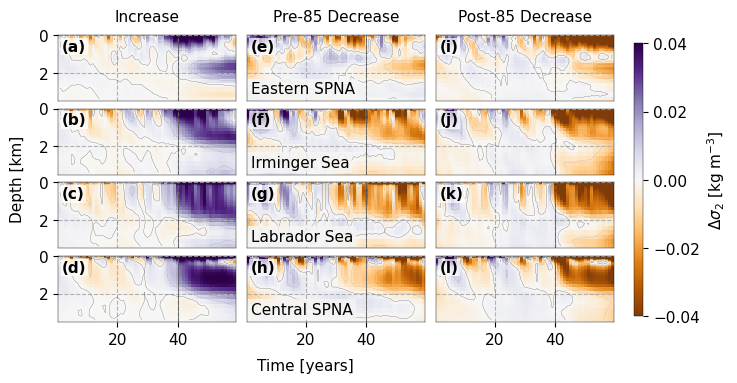

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 0. CONFIGURATION & GRID DIMENSIONS ---
REGION_MAPS = [
    ('esp', 'Eastern SPNA', esp_mask3d), 
    ('irm', 'Irminger Sea', irm_mask3d), 
    ('lab', 'Labrador Sea', lab_mask3d), 
    ('csp', 'Central SPNA', csp_mask3d)
]

start_time = 1
depth_range = [0, 350000] 
vmin, vmax = -0.04, 0.04
contour_levels = np.linspace(vmin, vmax, 11)

col_keys = list(all_anomalies.keys()) 
REGION_MAPS_PLOT = [(item[0], item[1]) for item in REGION_MAPS]
num_rows = len(REGION_MAPS_PLOT)
num_cols = len(col_keys)

# --- 1. SETUP FIGURE ---
fig, axes = plt.subplots(num_rows, num_cols, sharey='row') 

for ax_row in axes:
    for ax in ax_row:
        for spine in ax.spines.values():
            spine.set_linewidth(0.3)

pc = None 

# --- 2. PLOTTING LOOP ---
for j, col_key in enumerate(col_keys): 
    current_column_data = all_anomalies[col_key]
    
    for i, (region_key, region_title) in enumerate(REGION_MAPS_PLOT):
        data, stored_title = current_column_data[region_key] 
        ax = axes[i, j] 
        
        time_coords = ds_dens_increase.time.sel(time=slice(start_time, None))
        z_t_coords = ds_dens_increase.z_t.sel(z_t=slice(*depth_range))
        data_slice = data.sel(time=slice(start_time, None), z_t=slice(*depth_range)).T
        
        ax.set_facecolor('whitesmoke')
        pc = ax.pcolormesh(
            time_coords, 
            z_t_coords,
            data_slice, 
            cmap=plt.cm.PuOr, 
            vmin=vmin, vmax=vmax)
            
        ax.contour(time_coords, z_t_coords, data_slice, 
                   levels=contour_levels, colors='#4d4d4d', linewidths=0.1, alpha=0.8)

        ax.contour(time_coords, z_t_coords, data_slice, 
                   levels=[0], linewidths=0.1, colors='#292929')
        
        ax.axvline(40, color='#292929', linestyle='-', linewidth=0.5, alpha=0.8, zorder=12)
        
        label_index = (j * num_rows) + i
        label_text = f"({chr(97 + label_index)})"
        ax.text(0.02, 0.94, label_text, transform=ax.transAxes, fontweight='bold',
                verticalalignment='top',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1),
                zorder=15)
        
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major') 
        
        # Formatter set to integer km (0, 1, 2, 3)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/100000)}'))
        ax.grid(True, linestyle='--') 
        
        if i != num_rows - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        if j != 0:
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        if j == 1:
            ax.text(0.02, 0.07, region_title, transform=ax.transAxes,
                    verticalalignment='bottom', 
                    bbox={'boxstyle': 'square,pad=0.2', 'facecolor': 'whitesmoke', 'edgecolor': 'none', 'alpha': 0.8}, 
                    zorder=10)


# --- 3. FINAL FIGURE ADJUSTMENTS ---
axes[1, 0].set_ylabel('Depth [km]               ', labelpad=10, rotation='vertical') 
fig.text(0.5, 0.005, 'Time [years]', ha='center', va='bottom')

axes[0, 0].set_title("Increase", pad=10)
axes[0, 1].set_title("Pre-85 Decrease", pad=10)
axes[0, 2].set_title("Post-85 Decrease", pad=10)
 
cbar_ax = fig.add_axes([1.005, 0.15, 0.015, 0.7]) 
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$\Delta \sigma_2$ [kg m$^{-3}$]')
cbar.locator = ticker.MaxNLocator(nbins=5) 
cbar.update_ticks()

cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.3)

plt.tight_layout(rect=[0.02, 0.03, 1, 0.98], w_pad=0.7, h_pad=0.1)
plt.savefig('Figure_Depth_Density.png', bbox_inches='tight', transparent=False)

/tmp/ipykernel_2018642/2092422698.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.03, 1, 0.98], w_pad=0.7, h_pad=0.1)


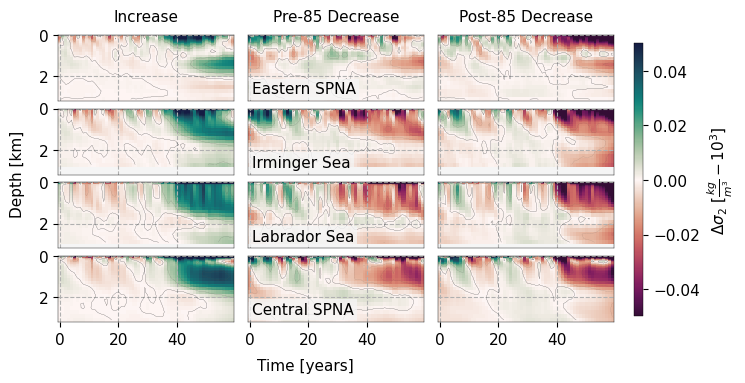

In [93]:
# --- 1. SETUP FIGURE ---
# Matplotlib will now use the figure.figsize defined in plt.rcParams: (6.5, 3.9)
fig, axes = plt.subplots(num_rows, num_cols, sharey='row') 

# Apply spine width to all subplots
for ax_row in axes:
    for ax in ax_row:
        for spine in ax.spines.values():
            spine.set_linewidth(0.3)

pc = None # Initialize pc for the colorbar

# --- 2. PLOTTING LOOP ---


for j, col_key in enumerate(col_keys): 
    current_column_data = all_anomalies[col_key]
    
    for i, (region_key, region_title) in enumerate(REGION_MAPS_PLOT):
        
        data, stored_title = current_column_data[region_key] 
        ax = axes[i, j] 
        
        # Select coordinates (using ds_dens_increase as the coordinate source)
        time_coords = ds_dens_increase.time.sel(time=slice(start_time, None))
        z_t_coords = ds_dens_increase.z_t.sel(z_t=slice(*depth_range))
        data_slice = data.sel(time=slice(start_time, None), z_t=slice(*depth_range)).T
        
        # --- Pcolormesh (Filled Colors) ---
        ax.set_facecolor('whitesmoke')
        pc = ax.pcolormesh(
            time_coords, 
            z_t_coords,
            data_slice, 
            cmap=cmo.curl_r,
            vmin=vmin, vmax=vmax)
            
        # --- Contour (Main levels) ---
        ax.contour(
            time_coords, 
            z_t_coords, 
            data_slice, 
            levels=contour_levels, 
            colors='#4d4d4d', 
            linewidths=0.1, 
            alpha=0.8
        )

        # --- Contour (Zero line) ---
        ax.contour(
            time_coords, 
            z_t_coords, 
            data_slice, 
            levels=[0], 
            linewidths=0.1, 
            colors='#292929'
        )
        
        ax.invert_yaxis()
        # Tick parameters inherit font.size from rcParams
        ax.tick_params(axis='both', which='major') 
        
        # Format Y-axis ticks to show depth in km
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/100000)}'))
        ax.grid(True, linestyle='--') 
        
        # --- Label Hiding Logic ---
        if i != num_rows - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        if j != 0:
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        if j == 1:
            ax.text(0.02, 0.07, region_title, transform=ax.transAxes,
                    verticalalignment='bottom', 
                    bbox={'boxstyle': 'square,pad=0.2', 'facecolor': 'whitesmoke', 'edgecolor': 'none', 'alpha': 0.8}, 
                    zorder=10)


# --- 3. FINAL FIGURE ADJUSTMENTS ---

# Shared Figure Labels (Centred) - Use default font.size
axes[1, 0].set_ylabel('Depth [km]             ', labelpad=10, rotation='vertical') 
fig.text(0.5, 0.005, 'Time [years]', ha='center', va='bottom') # Only keep the X-axis label

# Column Titles (Top Row) - Use axes.titlesize from rcParams
axes[0, 0].set_title("Increase", pad=10)
axes[0, 1].set_title("Pre-85 Decrease", pad=10)
axes[0, 2].set_title("Post-85 Decrease", pad=10)
 
# Colorbar 
cbar_ax = fig.add_axes([1.005, 0.15, 0.015, 0.7]) 
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$\Delta \sigma_2$ [$\frac{kg}{m^3} - 10^3$]')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.3)

# Use tight_layout and show plot
plt.tight_layout(rect=[0.02, 0.03, 1, 0.98], w_pad=0.7, h_pad=0.1)
#plt.show()
plt.savefig('Figure_Depth_Density.png', bbox_inches='tight', transparent=True)